# 9 billones de letras. Todo lo que la vida ha escrito. ¿Puede una IA aprenderlo?

> **Paper:** Nguyen, E. et al. (2026). *Sequence modeling and design from molecular to genome scale with Evo 2.* Nature.
> DOI: [10.1038/s41586-026-10176-5](https://doi.org//10.1038/s41586-026-10176-5)
>
> [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-09-evo2-ia-adn-escribir-vida/notebook.ipynb)
> [Ver el video](https://youtube.com/shorts/i-yFdSiK6m4)

Cada organismo vivo almacena su receta en ADN: una secuencia de letras (A, T, C, G) que codifica proteínas, reguladores y señales. Secuenciar genomas se volvió rutina, pero *entender* qué significa cada letra —y qué pasa si cambia— sigue siendo uno de los mayores retos de la biología.

Evo 2 es un modelo de IA entrenado con 9 billones de pares de bases de ADN, tomados de todos los dominios de la vida: bacterias, arqueas, eucariotas. Con 40.000 millones de parámetros y una ventana de contexto de 1 millón de tokens, puede leer secuencias genómicas completas con resolución de un solo nucleótido. Lo más llamativo: predice el impacto funcional de mutaciones *sin* haber sido entrenado específicamente para eso (zero-shot).

Veamos cómo le va contra los modelos especializados que llevan años en cada nicho.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TITULO_PAPER = '9 billones de bases de ADN enseñaron a una IA a escribir vida'
DOI = '10.1038/s41586-026-10176-5'
FUENTE = 'Fuente: Nguyen et al. (2026), Nature | Datos: Supplementary Table 3'

COLOR_EVO2 = '#2563EB'       # Azul CaM — Evo 2
COLOR_EVO1 = '#BBBBBB'       # Gris — Evo 1
COLOR_ESPECIALIZADO = '#DC2626'  # Rojo — mejores especializados
COLOR_OTROS = '#D1D5DB'      # Gris claro — otros modelos
COLOR_BRCA = '#059669'        # Emerald — BRCA1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
df = pd.read_csv('datos/benchmarks_variantes.csv')

# Resumen
print(f"Comparaciones: {len(df)}")
print(f"Modelos: {df['model'].nunique()}")
print(f"Datasets: {', '.join(df['dataset'].unique())}")
print(f"\nAUROC global: media={df['auroc'].mean():.3f}, mediana={df['auroc'].median():.3f}")
print(f"Evo 2 40B mediana AUROC: {df[df['model']=='Evo 2 40B']['auroc'].median():.3f}")

Comparaciones: 705
Modelos: 25
Datasets: ClinVar, SpliceVarDB, BRCA2, BRCA1

AUROC global: media=0.762, mediana=0.804
Evo 2 40B mediana AUROC: 0.893


Empecemos por el benchmark más importante: variantes patogénicas de ClinVar. Miles de mutaciones humanas clasificadas como dañinas o benignas. ¿Quién las distingue mejor?

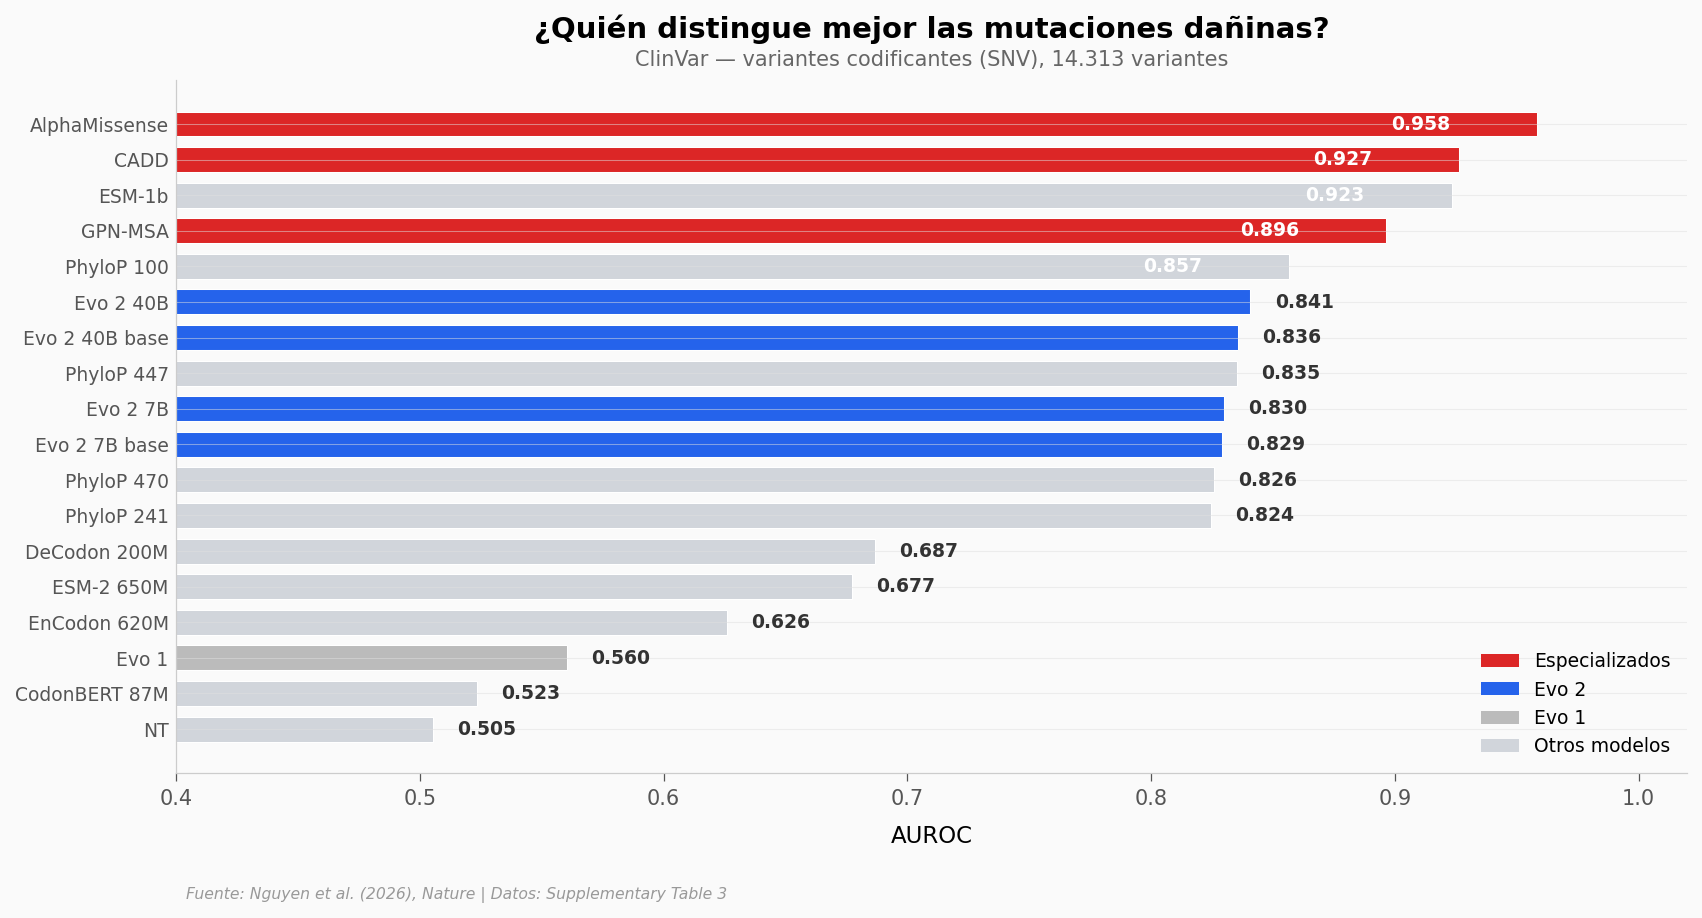

In [2]:
# Variantes codificantes de ClinVar (SNV) — el benchmark estrella
mask = ((df['dataset'] == 'ClinVar') &
        (df['genomic_feature'] == 'Coding') &
        (df['variant_type'] == 'SNV') &
        (df['sub_category'].isna()))
coding = df[mask].sort_values('auroc', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))

# Colores por tipo de modelo
colors = []
for m in coding['model']:
    if 'Evo 2' in m:
        colors.append(COLOR_EVO2)
    elif m == 'Evo 1':
        colors.append(COLOR_EVO1)
    elif m in ['AlphaMissense', 'CADD', 'SpliceAI', 'GPN-MSA']:
        colors.append(COLOR_ESPECIALIZADO)
    else:
        colors.append(COLOR_OTROS)

bars = ax.barh(range(len(coding)), coding['auroc'], color=colors, edgecolor='white', linewidth=0.5, height=0.7)

# Etiquetas con AUROC
for i, (auroc, model) in enumerate(zip(coding['auroc'], coding['model'])):
    offset = 0.01 if auroc < 0.85 else -0.06
    color = 'white' if auroc >= 0.85 and offset < 0 else '#333333'
    ax.text(auroc + offset, i, f'{auroc:.3f}', va='center', fontsize=9, fontweight='bold', color=color)

ax.set_yticks(range(len(coding)))
ax.set_yticklabels(coding['model'], fontsize=9)
ax.set_xlim(0.4, 1.02)
ax.set_xlabel('AUROC', fontsize=11)
ax.set_title('¿Quién distingue mejor las mutaciones dañinas?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'ClinVar — variantes codificantes (SNV), 14.313 variantes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_ESPECIALIZADO, label='Especializados'),
    Patch(facecolor=COLOR_EVO2, label='Evo 2'),
    Patch(facecolor=COLOR_EVO1, label='Evo 1'),
    Patch(facecolor=COLOR_OTROS, label='Otros modelos'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/clinvar_coding_ranking.png', dpi=200, bbox_inches='tight')
plt.show()

AlphaMissense lidera con un AUROC de 0,958 — pero es un modelo diseñado *exclusivamente* para predecir el efecto de mutaciones en proteínas. CADD y ESM-1b completan el podio con estrategias igualmente especializadas.

Evo 2 40B aparece en el puesto 6 con 0,841. No es el mejor aquí. Pero hay un detalle crucial: Evo 2 *no fue entrenado para esta tarea*. Es un modelo generalista que solo aprendió a leer secuencias de ADN, sin etiquetas de "dañina" o "benigna". Que distinga variantes patogénicas de benignas con un AUROC de 0,841 *sin instrucción específica* es lo sorprendente.

Y miremos la parte de abajo: Evo 1, la versión anterior, apenas supera el azar (0,560). El salto de una generación a otra es enorme.

Pero las variantes codificantes son solo una parte del genoma. El 98% del ADN humano es *no codificante* — regiones reguladoras, intrones, secuencias entre genes. Los modelos de proteínas no pueden operar ahí. ¿Y en el gen del cáncer de mama, BRCA1?

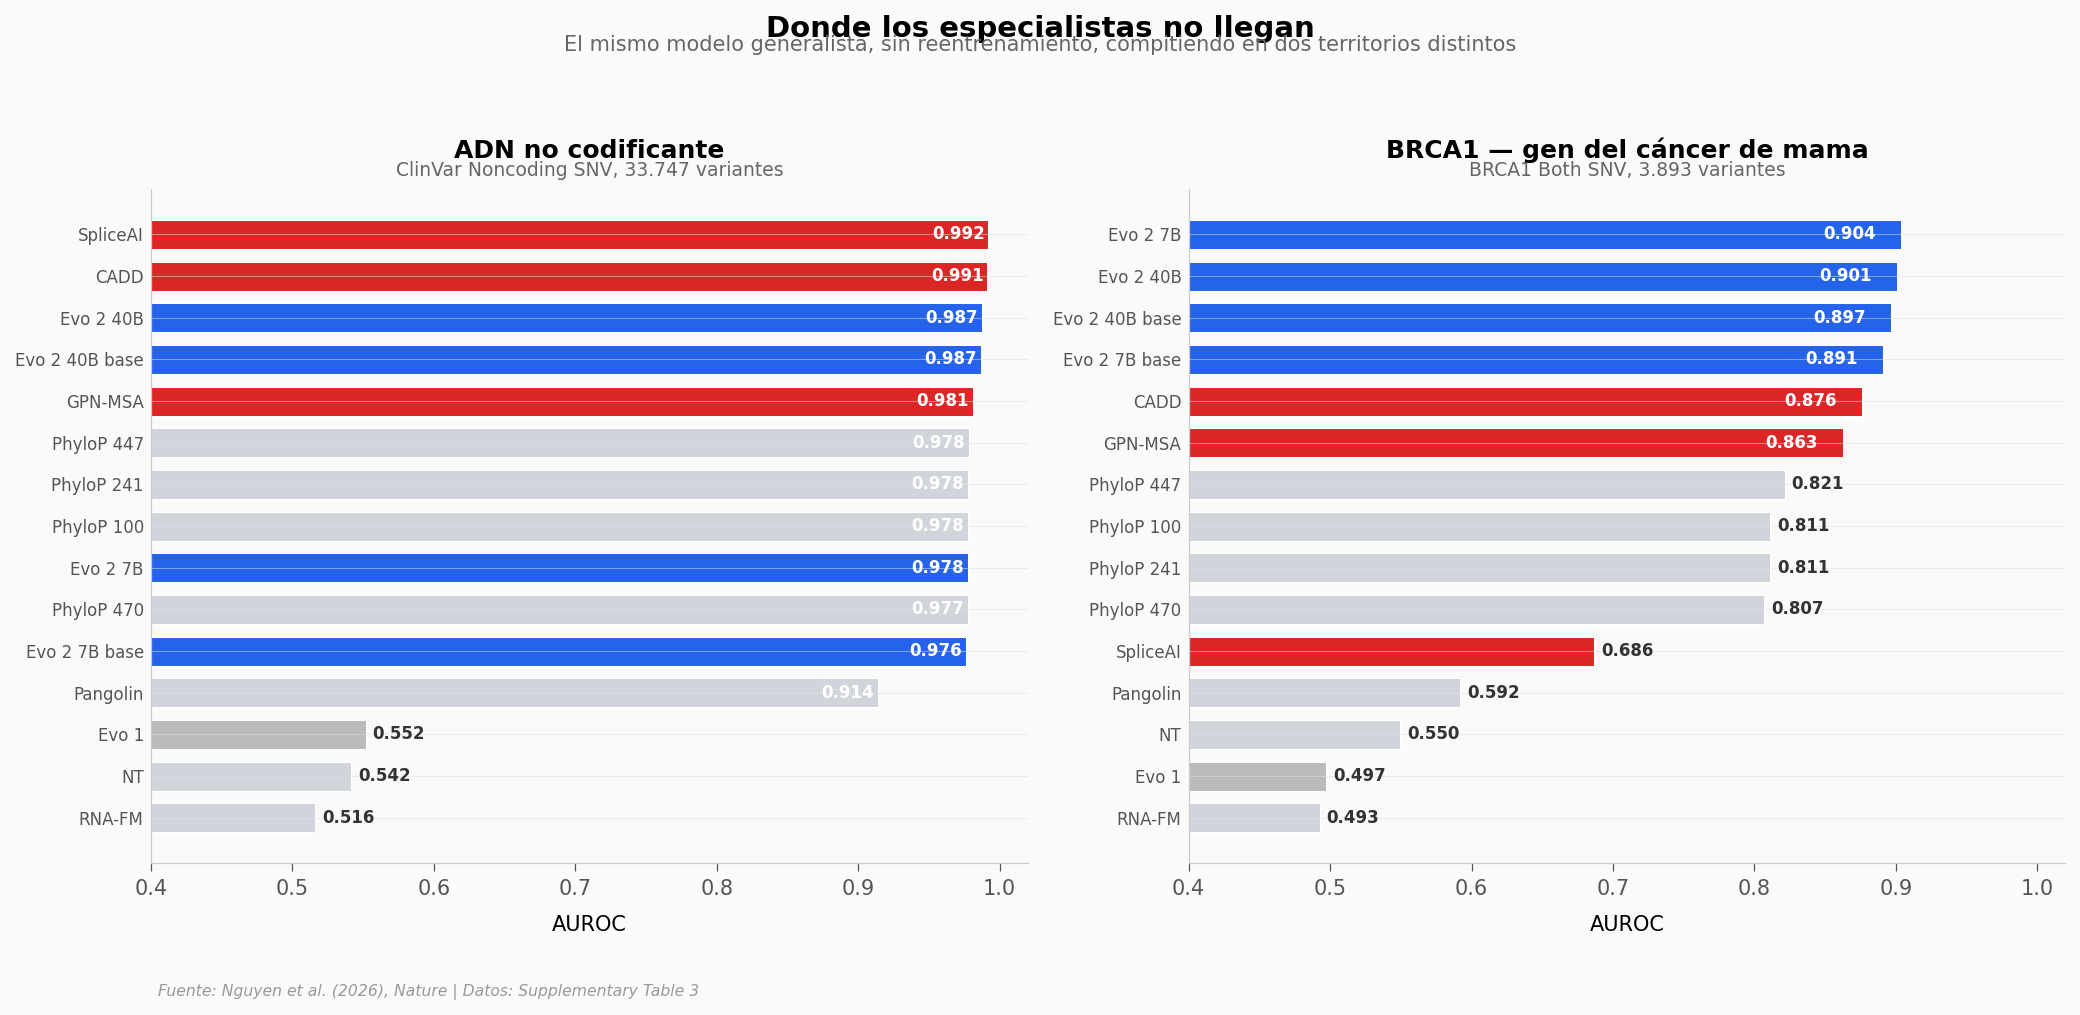

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel 1: ClinVar Noncoding SNV ──
mask_nc = ((df['dataset'] == 'ClinVar') &
           (df['genomic_feature'] == 'Noncoding') &
           (df['variant_type'] == 'SNV') &
           (df['sub_category'].isna()))
nc = df[mask_nc].sort_values('auroc', ascending=True).reset_index(drop=True)

colors_nc = []
for m in nc['model']:
    if 'Evo 2' in m:
        colors_nc.append(COLOR_EVO2)
    elif m == 'Evo 1':
        colors_nc.append(COLOR_EVO1)
    elif m in ['SpliceAI', 'CADD', 'GPN-MSA']:
        colors_nc.append(COLOR_ESPECIALIZADO)
    else:
        colors_nc.append(COLOR_OTROS)

ax1.barh(range(len(nc)), nc['auroc'], color=colors_nc, edgecolor='white', linewidth=0.5, height=0.7)
for i, (auroc, model) in enumerate(zip(nc['auroc'], nc['model'])):
    offset = 0.005 if auroc < 0.9 else -0.04
    color = 'white' if auroc >= 0.9 and offset < 0 else '#333333'
    ax1.text(auroc + offset, i, f'{auroc:.3f}', va='center', fontsize=8, fontweight='bold', color=color)

ax1.set_yticks(range(len(nc)))
ax1.set_yticklabels(nc['model'], fontsize=8)
ax1.set_xlim(0.4, 1.02)
ax1.set_xlabel('AUROC', fontsize=10)
ax1.set_title('ADN no codificante', fontsize=12, fontweight='bold', pad=15)
ax1.text(0.5, 1.02, 'ClinVar Noncoding SNV, 33.747 variantes',
         transform=ax1.transAxes, fontsize=9, color='#666666', ha='center')

# ── Panel 2: BRCA1 ──
mask_brca = ((df['dataset'] == 'BRCA1') &
             (df['genomic_feature'] == 'Both') &
             (df['variant_type'] == 'SNV'))
brca = df[mask_brca].sort_values('auroc', ascending=True).reset_index(drop=True)

colors_brca = []
for m in brca['model']:
    if 'Evo 2' in m:
        colors_brca.append(COLOR_EVO2)
    elif m == 'Evo 1':
        colors_brca.append(COLOR_EVO1)
    elif m in ['CADD', 'GPN-MSA', 'SpliceAI']:
        colors_brca.append(COLOR_ESPECIALIZADO)
    else:
        colors_brca.append(COLOR_OTROS)

ax2.barh(range(len(brca)), brca['auroc'], color=colors_brca, edgecolor='white', linewidth=0.5, height=0.7)
for i, (auroc, model) in enumerate(zip(brca['auroc'], brca['model'])):
    offset = 0.005 if auroc < 0.85 else -0.055
    color = 'white' if auroc >= 0.85 and offset < 0 else '#333333'
    ax2.text(auroc + offset, i, f'{auroc:.3f}', va='center', fontsize=8, fontweight='bold', color=color)

ax2.set_yticks(range(len(brca)))
ax2.set_yticklabels(brca['model'], fontsize=8)
ax2.set_xlim(0.4, 1.02)
ax2.set_xlabel('AUROC', fontsize=10)
ax2.set_title('BRCA1 — gen del cáncer de mama', fontsize=12, fontweight='bold', pad=15)
ax2.text(0.5, 1.02, 'BRCA1 Both SNV, 3.893 variantes',
         transform=ax2.transAxes, fontsize=9, color='#666666', ha='center')

fig.suptitle('Donde los especialistas no llegan', fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'El mismo modelo generalista, sin reentrenamiento, compitiendo en dos territorios distintos',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.08, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/noncoding_brca1.png', dpi=200, bbox_inches='tight')
plt.show()

En el ADN no codificante, Evo 2 trepa al tercer puesto (0,987) — apenas por detrás de SpliceAI (0,992) y CADD (0,991), ambos diseñados para este dominio. Pero es en BRCA1 donde ocurre algo inesperado: Evo 2 es el mejor. Los modelos Evo 2 7B (0,904) y 40B (0,901) superan a CADD, a GPN-MSA y a todos los demás.

¿Y la versión anterior? Evo 1 apenas roza el azar en ambos paneles. La distancia entre generaciones es enorme. Veamos cuánto.

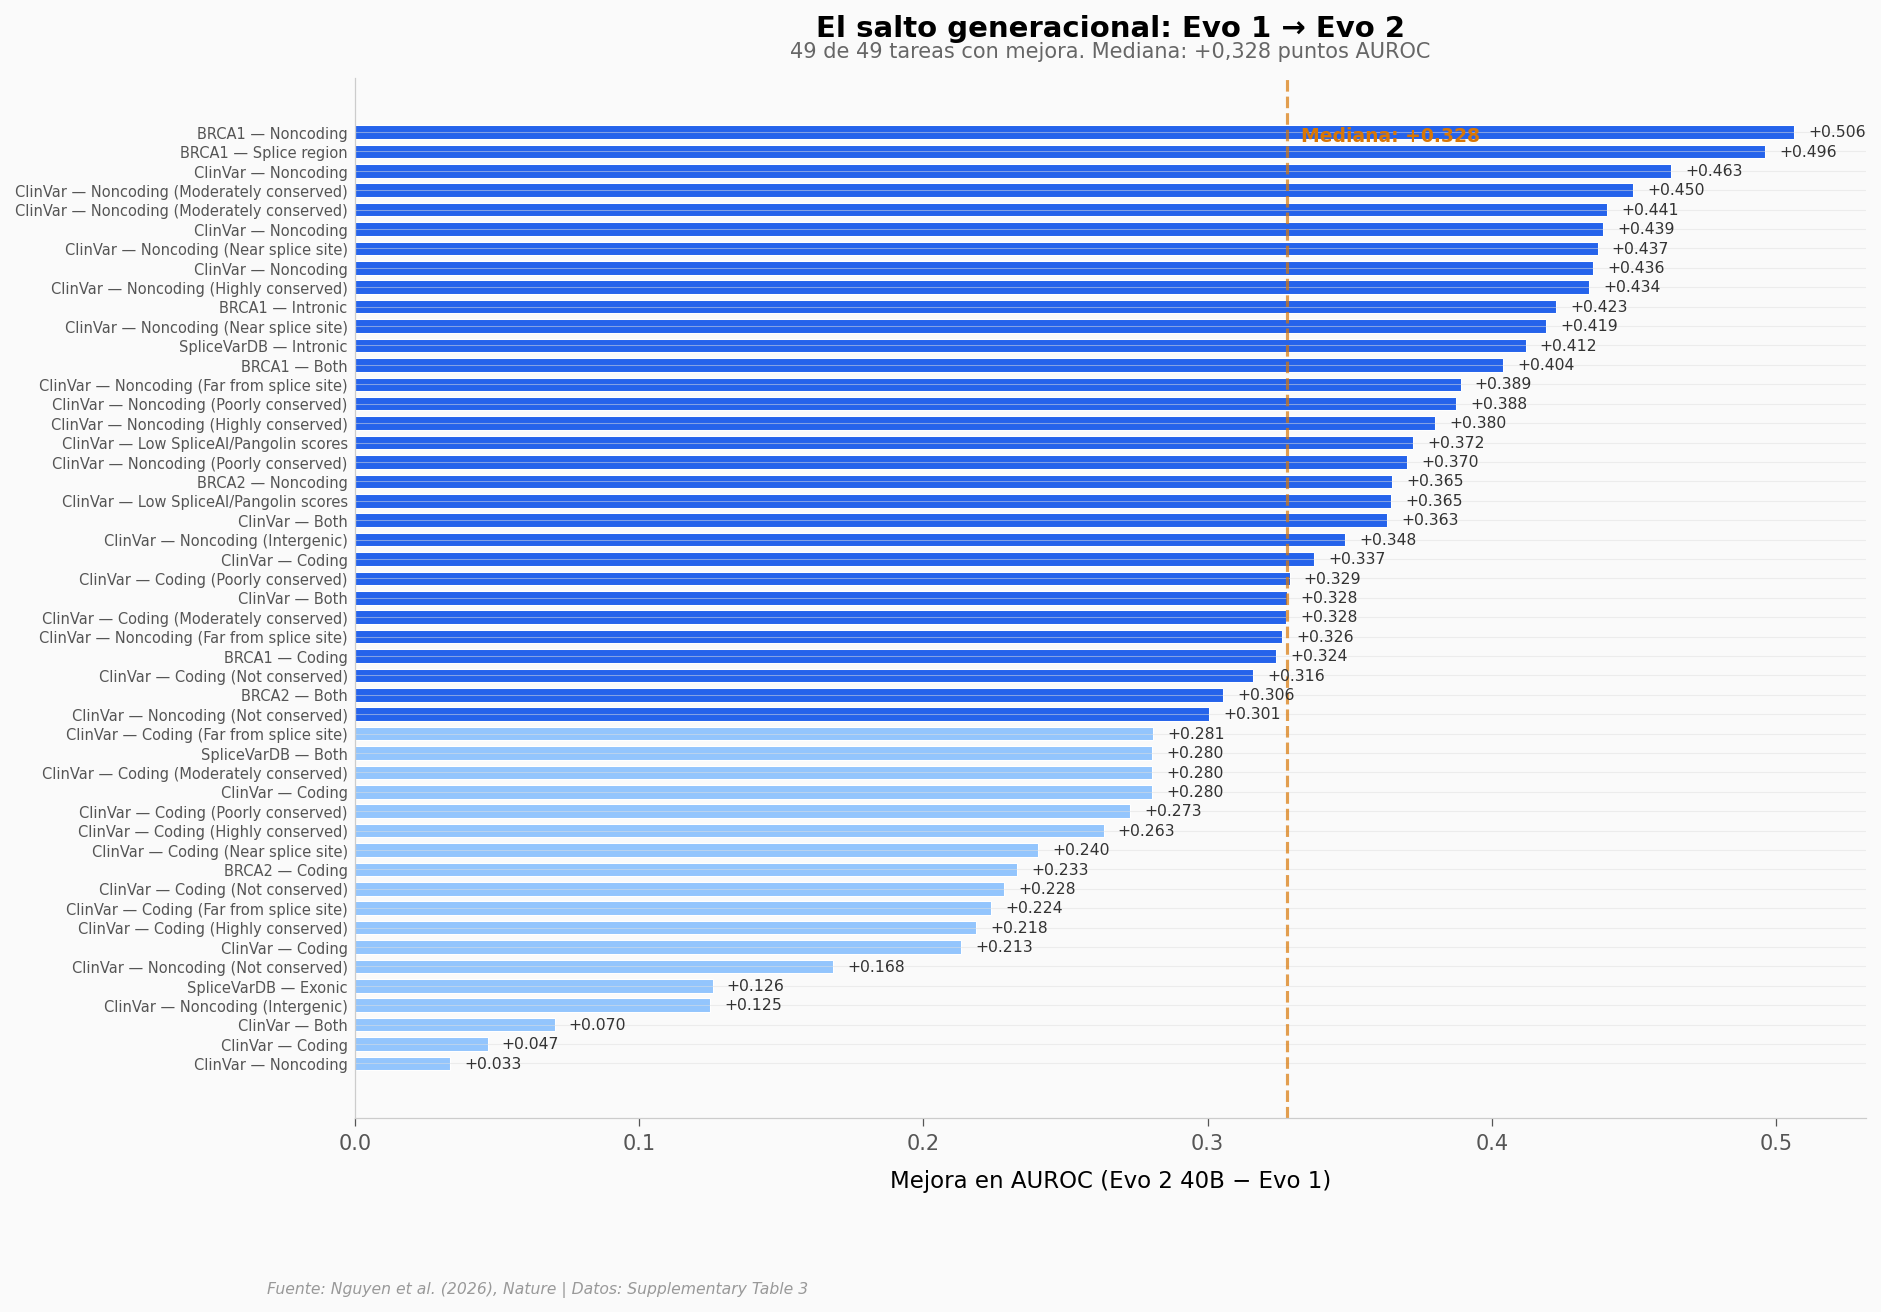

Evo 2 supera a Evo 1 en 49/49 tareas (100%)
Mejora mínima: +0.033
Mejora máxima: +0.506


In [4]:
# Mejora Evo 1 → Evo 2 40B en TODAS las tareas
evo2_tasks = df[df['model'] == 'Evo 2 40B'][['dataset', 'genomic_feature', 'variant_type', 'sub_category', 'auroc']]
evo1_tasks = df[df['model'] == 'Evo 1'][['dataset', 'genomic_feature', 'variant_type', 'sub_category', 'auroc']]

merged = pd.merge(evo2_tasks, evo1_tasks,
                  on=['dataset', 'genomic_feature', 'variant_type', 'sub_category'],
                  suffixes=('_evo2', '_evo1'))
merged['mejora'] = merged['auroc_evo2'] - merged['auroc_evo1']
merged = merged.sort_values('mejora', ascending=True).reset_index(drop=True)

# Etiqueta legible
merged['tarea'] = merged['dataset'] + ' — ' + merged['genomic_feature']
sc = merged['sub_category'].fillna('')
merged.loc[sc != '', 'tarea'] = merged.loc[sc != '', 'tarea'] + ' (' + sc[sc != ''] + ')'

fig, ax = plt.subplots(figsize=(13, 9))

# Color por magnitud de mejora
colors_imp = [COLOR_EVO2 if m > 0.3 else '#93C5FD' for m in merged['mejora']]

ax.barh(range(len(merged)), merged['mejora'], color=colors_imp,
        edgecolor='white', linewidth=0.5, height=0.7)

# Anotar valor
for i, m in enumerate(merged['mejora']):
    ax.text(m + 0.005, i, f'+{m:.3f}', va='center', fontsize=7.5, color='#333333')

ax.set_yticks(range(len(merged)))
ax.set_yticklabels(merged['tarea'], fontsize=7)
ax.set_xlabel('Mejora en AUROC (Evo 2 40B − Evo 1)', fontsize=11)
ax.set_title('El salto generacional: Evo 1 → Evo 2',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'49 de 49 tareas con mejora. Mediana: +0,328 puntos AUROC',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Línea de referencia en mediana
median_imp = merged['mejora'].median()
ax.axvline(x=median_imp, color='#D97706', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(median_imp + 0.005, len(merged) - 1.5, f'Mediana: +{median_imp:.3f}',
        fontsize=9, color='#D97706', fontweight='bold')

fig.text(0.08, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mejora_evo1_evo2.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Evo 2 supera a Evo 1 en {(merged['mejora'] > 0).sum()}/{len(merged)} tareas (100%)")
print(f"Mejora mínima: +{merged['mejora'].min():.3f}")
print(f"Mejora máxima: +{merged['mejora'].max():.3f}")

49 de 49 tareas con mejora. Ni una sola excepción. La mejora mínima es +0,033 y la máxima supera +0,5 puntos de AUROC. La mediana es +0,328 — un salto que rara vez se ve entre generaciones de un mismo modelo.

¿Y cómo se ve Evo 2 en el paisaje completo de todos los modelos?

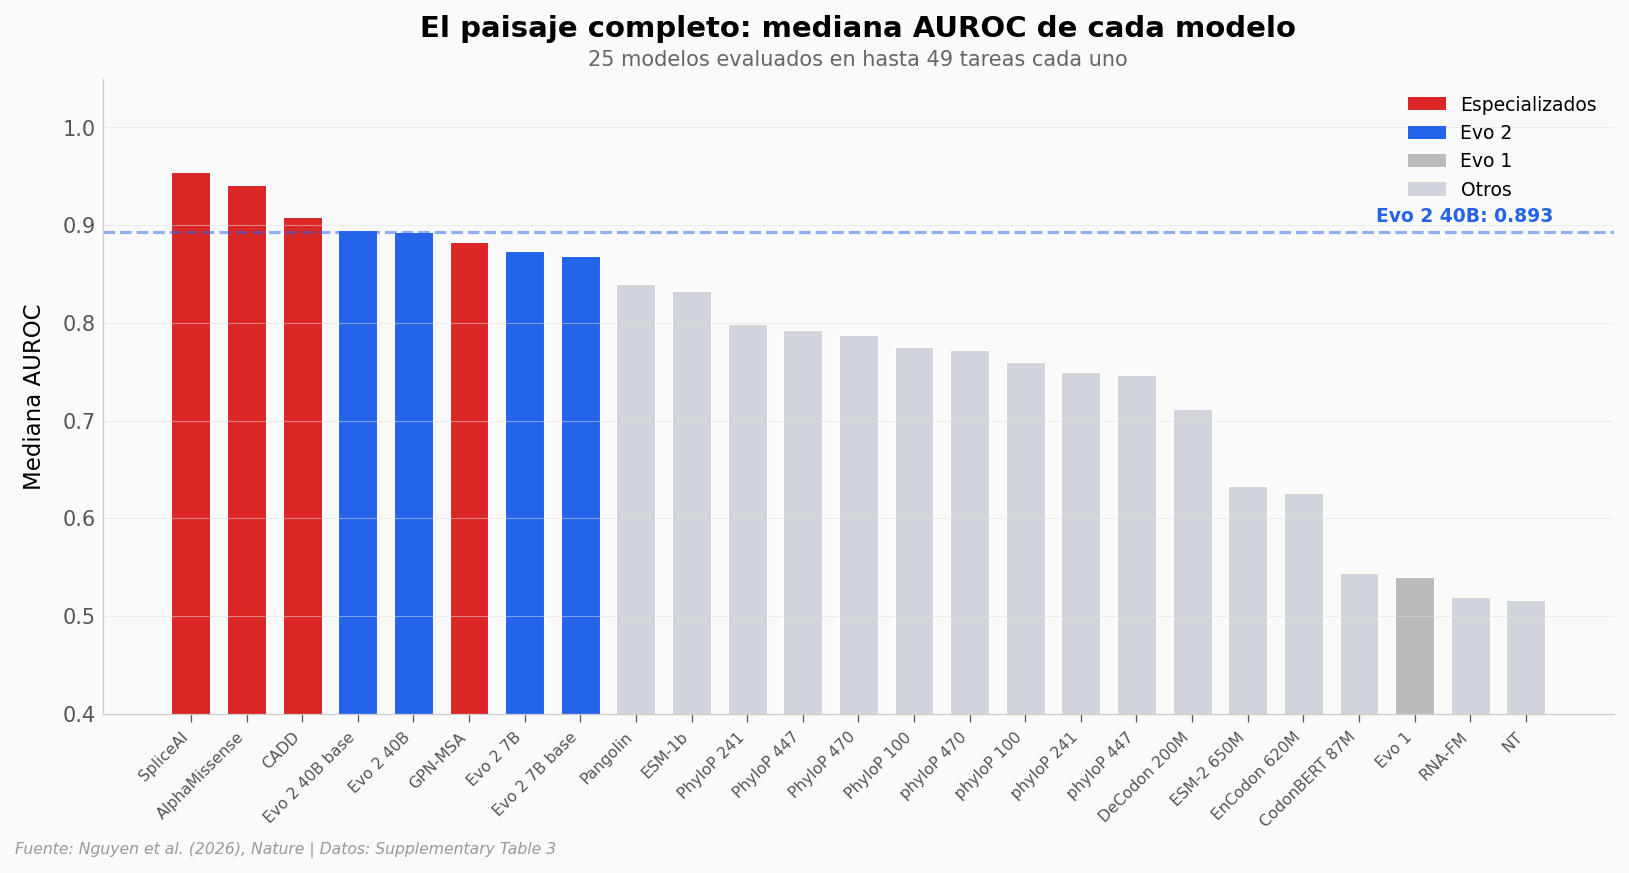

In [5]:
# Distribución AUROC de cada modelo (mediana por modelo vs todos)
model_stats = df.groupby('model')['auroc'].agg(['median', 'count']).sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5.5))

# Todos los modelos
colors_hist = []
labels_show = []
for m in model_stats.index:
    if 'Evo 2' in m:
        colors_hist.append(COLOR_EVO2)
    elif m == 'Evo 1':
        colors_hist.append(COLOR_EVO1)
    elif m in ['AlphaMissense', 'CADD', 'SpliceAI', 'GPN-MSA']:
        colors_hist.append(COLOR_ESPECIALIZADO)
    else:
        colors_hist.append(COLOR_OTROS)

x = range(len(model_stats))
bars = ax.bar(x, model_stats['median'], color=colors_hist, edgecolor='white', linewidth=0.5, width=0.7)

ax.set_xticks(x)
ax.set_xticklabels(model_stats.index, fontsize=7.5, rotation=45, ha='right')
ax.set_ylabel('Mediana AUROC', fontsize=11)
ax.set_ylim(0.4, 1.05)
ax.set_title('El paisaje completo: mediana AUROC de cada modelo',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '25 modelos evaluados en hasta 49 tareas cada uno',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Línea de Evo 2 40B
evo2_median = model_stats.loc['Evo 2 40B', 'median']
ax.axhline(y=evo2_median, color=COLOR_EVO2, linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(len(model_stats) - 0.5, evo2_median + 0.01, f'Evo 2 40B: {evo2_median:.3f}',
        fontsize=9, color=COLOR_EVO2, fontweight='bold', ha='right')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_ESPECIALIZADO, label='Especializados'),
    Patch(facecolor=COLOR_EVO2, label='Evo 2'),
    Patch(facecolor=COLOR_EVO1, label='Evo 1'),
    Patch(facecolor=COLOR_OTROS, label='Otros'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.08, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/panorama_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Evo 2 predice el impacto funcional de variantes sin entrenamiento específico | ✅ | AUROC mediana 0,893 en 49 tareas zero-shot — consistentemente por encima del azar |
| Evo 2 supera a todos los modelos especializados | ❌ | AlphaMissense (0,958) y SpliceAI (0,992) lo superan en sus dominios (coding y noncoding, respectivamente) |
| Evo 2 es competitivo en todas las categorías | ✅ | Top 3 en 55% de las tareas (27/49), mediana AUROC 0,893, rango 0,684–0,997 |
| Evo 2 es el mejor predictor de variantes BRCA1 | ✅ | Evo 2 7B: AUROC 0,904 (#1), Evo 2 40B: 0,901 (#2) sobre 3.893 variantes |
| Evo 2 mejora drásticamente sobre Evo 1 | ✅ | Mejora en 49/49 tareas (100%), mediana +0,328 puntos AUROC |
| Los resultados aplican a diagnóstico clínico | ⚠️ | Son benchmarks in silico. Un AUROC de 0,90 clasifica bien pero no sustituye validación clínica |

> **Limitaciones:** Los datos son de benchmarks computacionales, no de aplicaciones clínicas. Los datasets (ClinVar, BRCA1) contienen variantes ya clasificadas — el rendimiento en variantes de significado incierto (VUS) podría diferir. El ranking depende del dataset y tipo de variante; ningún modelo es universalmente superior.

---

## Ahora tú

1. **¿Importa el tamaño?** Evo 2 viene en versiones de 7B y 40B parámetros. ¿El modelo grande siempre gana? Filtra los datos por `Evo 2 7B` vs `Evo 2 40B` y compara sus AUROC por tarea. Pista: en BRCA1, el 7B gana.

2. **¿Cuánto pesa la conservación?** ClinVar tiene subcategorías por nivel de conservación evolutiva (Highly conserved, Not conserved...). ¿Evo 2 rinde mejor en regiones conservadas? Filtra por `sub_category` y grafícalo.

3. **¿SNV vs inserciones/deleciones?** Los modelos pueden comportarse muy distinto con variantes de un solo nucleótido (SNV) vs indels. Compara el AUROC de Evo 2 40B entre `variant_type == 'SNV'` y `variant_type == 'non-SNV'`.

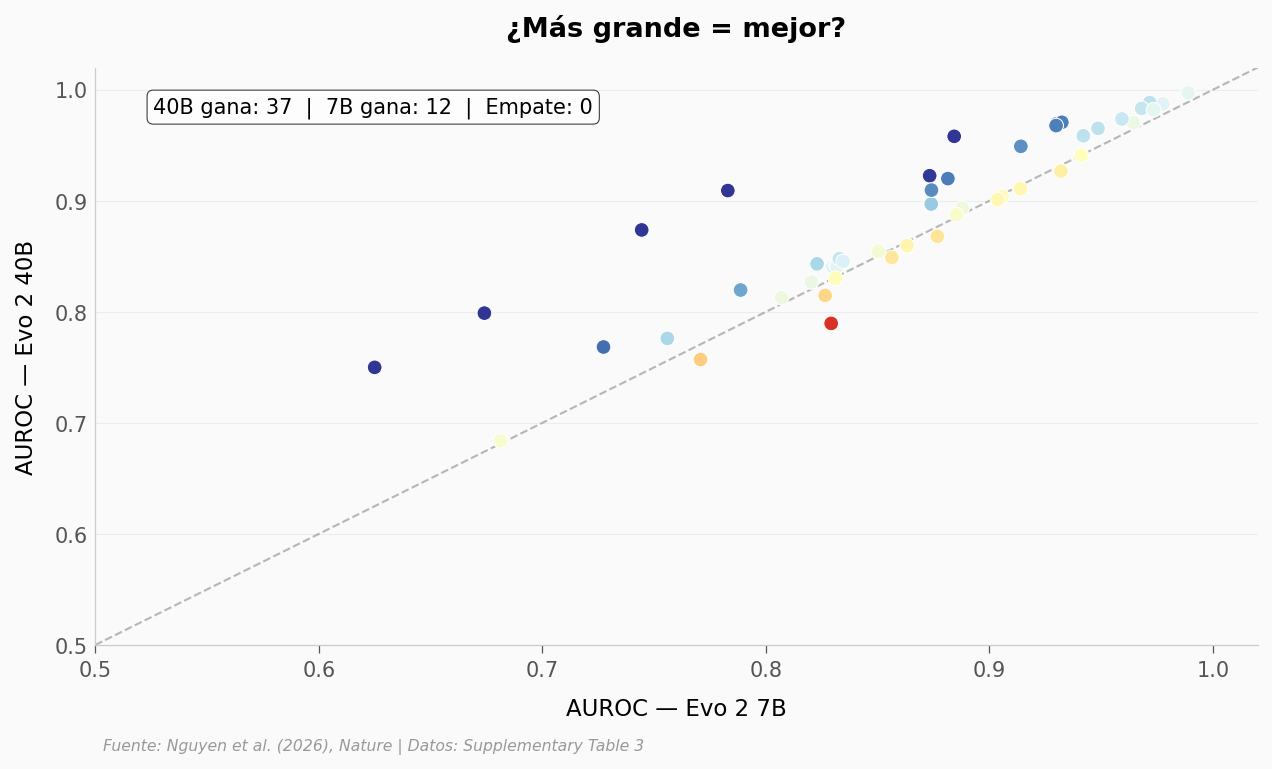

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Importa el tamaño del modelo? Evo 2 7B vs 40B
evo2_7b = df[df['model'] == 'Evo 2 7B'][['dataset', 'genomic_feature', 'variant_type', 'sub_category', 'auroc']]
evo2_40b = df[df['model'] == 'Evo 2 40B'][['dataset', 'genomic_feature', 'variant_type', 'sub_category', 'auroc']]

comp = pd.merge(evo2_7b, evo2_40b,
                on=['dataset', 'genomic_feature', 'variant_type', 'sub_category'],
                suffixes=('_7B', '_40B'))
comp['diff'] = comp['auroc_40B'] - comp['auroc_7B']

fig, ax = plt.subplots(figsize=(10, 5))
np.random.seed(42)
x_jitter = np.linspace(-0.15, 0.15, len(comp))
np.random.shuffle(x_jitter)

ax.scatter(comp['auroc_7B'], comp['auroc_40B'], c=comp['diff'],
           cmap='RdYlBu', s=50, edgecolors='white', linewidths=0.5,
           vmin=-0.05, vmax=0.05, zorder=5)

# Línea de igualdad
lims = [0.5, 1.02]
ax.plot(lims, lims, '--', color='#999999', linewidth=1, alpha=0.7)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('AUROC — Evo 2 7B', fontsize=11)
ax.set_ylabel('AUROC — Evo 2 40B', fontsize=11)
ax.set_title('¿Más grande = mejor?', fontsize=13, fontweight='bold', pad=15)

wins_40b = (comp['diff'] > 0).sum()
wins_7b = (comp['diff'] < 0).sum()
ties = (comp['diff'] == 0).sum()
ax.text(0.05, 0.95, f'40B gana: {wins_40b}  |  7B gana: {wins_7b}  |  Empate: {ties}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/7b_vs_40b.png', dpi=200, bbox_inches='tight')
plt.show()

---

**Datos:** Supplementary Table 3 de Nguyen, E. et al. (2026). *Sequence modeling and design from molecular to genome scale with Evo 2.* Nature. DOI: [10.1038/s41586-026-10176-5](https://doi.org/10.1038/s41586-026-10176-5)

**Repositorio de datos:** [arcinstitute/evo2](https://github.com/arcinstitute/evo2) — modelo, código de entrenamiento e inferencia, y dataset OpenGenome2 (abiertos)

**Licencia de datos:** Los Supplementary Materials de Nature se redistribuyen bajo los términos del artículo original (Creative Commons).

**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)